# Importación de librerías

In [1]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp
import numpy as np
from sklearn.decomposition import PCA

# Importación de datos

In [2]:
df = dp.lectura(mode=3) # Leyendo 3 primeros individuos
df_val = dp.lectura(mode=4) # Leyendo 10mo individuo

Se crea el dataframe df_block

In [3]:
df_block = dp.create_df_block(df)
df_block_val = dp.create_df_block(df_val)

In [4]:
del df
del df_val

Se limpia y visualiza el contenido

In [5]:
dp.balance(df_block)
dp.balance(df_block_val)
print(df_block['stimulus'].value_counts())
print(df_block_val['stimulus'].value_counts())

stimulus
1     348
0     348
3     348
4     348
6     348
9     348
10    348
11    348
Name: count, dtype: int64
stimulus
1     72
3     72
0     72
4     72
6     72
9     72
10    72
11    72
Name: count, dtype: int64


# Filtro

In [6]:
df_block_filtered = dp.filter(df_block)
df_block_filtered_val = dp.filter(df_block_val)

Procesando: 100%|██████████| 3/3 [00:19<00:00,  6.58s/it]


In [7]:
del df_block
del df_block_val

# Extracción de características

In [8]:
df_block_features = dp.get_carac(df_block_filtered)
df_block_features_val = dp.get_carac(df_block_filtered_val)

Extrayendo Características: 100%|██████████| 576/576 [01:24<00:00,  6.84it/s]


In [9]:
del df_block_filtered
del df_block_filtered_val

In [10]:
df_block_features.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus,Stimulus
count,2784.000000,2784.000000,2784.000000,2784.000000,2.784000e+03,2.784000e+03,2784.000000,2784.000000,2784.000000,2784.000000,...,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.000000,2784.0,2784.000000
mean,0.000019,0.111038,0.000012,0.029751,5.673768e-06,1.850486e-09,0.000012,0.074509,0.000008,0.016951,...,0.001012,220.594350,35.937141,818.484195,276.947198,46.578323,15.300618,0.312042,0.0,5.500000
std,0.000007,0.045096,0.000004,0.012923,2.279936e-06,1.532981e-09,0.000006,0.035184,0.000004,0.008249,...,0.000067,31.747352,6.308172,186.797116,107.920512,20.341817,8.436484,0.116367,0.0,3.905826
min,0.000002,0.016238,0.000002,0.003376,9.529709e-07,2.146418e-11,0.000002,0.010716,0.000001,0.002421,...,0.000447,71.202391,14.000000,92.000000,36.000000,0.196194,5.930983,0.163540,0.0,0.000000
25%,0.000014,0.078689,0.000009,0.020627,4.043928e-06,8.948986e-10,0.000009,0.050481,0.000005,0.011213,...,0.000980,196.942776,32.000000,688.000000,185.000000,31.934806,11.328849,0.255905,0.0,2.500000
50%,0.000018,0.105870,0.000011,0.027708,5.462312e-06,1.464066e-09,0.000012,0.071763,0.000008,0.016442,...,0.001007,212.621878,38.000000,767.000000,242.000000,42.277062,13.134854,0.274150,0.0,5.000000
75%,0.000022,0.136802,0.000014,0.037096,6.957430e-06,2.317191e-09,0.000015,0.092863,0.000010,0.021396,...,0.001039,254.331439,40.000000,1004.000000,392.000000,61.113487,16.658904,0.339518,0.0,9.250000
max,0.000062,0.383230,0.000038,0.110599,1.753282e-05,1.941526e-08,0.000091,0.383761,0.000041,0.093692,...,0.001430,263.492185,59.000000,1202.000000,522.000000,148.936170,233.048478,1.992581,0.0,11.000000


In [11]:
df_block_features_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus,Stimulus
count,576.000000,576.000000,576.000000,576.000000,576.000000,5.760000e+02,576.000000,576.000000,576.000000,576.000000,...,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.0,576.000000
mean,0.000032,0.174509,0.000018,0.043603,0.000009,1.443323e-08,0.000034,0.200535,0.000021,0.047639,...,0.000980,255.522991,40.446181,1016.631944,392.784722,46.103150,11.519315,0.263881,0.0,5.500000
std,0.000045,0.141599,0.000015,0.023988,0.000005,7.359946e-08,0.000018,0.078113,0.000008,0.019131,...,0.000035,3.200017,1.509582,114.143053,43.112135,21.277131,2.636465,0.014569,0.0,3.908519
min,0.000007,0.040718,0.000005,0.009734,0.000002,2.519427e-10,0.000007,0.041809,0.000004,0.008487,...,0.000756,244.902015,36.000000,506.000000,249.000000,0.196098,8.989898,0.229085,0.0,0.000000
25%,0.000018,0.106183,0.000011,0.027280,0.000006,1.462022e-09,0.000024,0.147046,0.000016,0.034268,...,0.000965,253.458065,39.000000,985.500000,375.000000,32.352156,10.461728,0.254975,0.0,2.500000
50%,0.000024,0.148038,0.000015,0.038574,0.000007,2.820599e-09,0.000032,0.196632,0.000021,0.047114,...,0.000983,255.661982,40.000000,1038.000000,399.000000,40.362018,11.166717,0.262627,0.0,5.000000
75%,0.000032,0.197471,0.000021,0.052501,0.000010,4.840828e-09,0.000039,0.245433,0.000026,0.060074,...,0.001000,257.598058,41.000000,1096.250000,420.250000,63.619048,12.114626,0.271868,0.0,9.250000
max,0.000408,1.336766,0.000143,0.168466,0.000041,8.254571e-07,0.000274,0.648768,0.000073,0.117198,...,0.001080,266.462495,44.000000,1226.000000,503.000000,147.375079,54.459434,0.355325,0.0,11.000000


# Normalización

In [12]:
scaler, df_block_normalized = dp.normalize(df_block_features)
df_block_normalized_val = dp.normalize(df_block_features_val, scaler)

In [13]:
del df_block_features
del df_block_features_val

In [14]:
df_block_normalized.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus,Stimulus
count,2784.000000,2.784000e+03,2784.000000,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,...,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2.784000e+03,2784.0,2784.000000
mean,0.000000,-2.348058e-16,0.000000,-2.041789e-16,2.807461e-16,-1.225074e-16,-1.837611e-16,6.125368e-17,-2.960595e-16,-2.552237e-16,...,-2.000954e-15,3.266863e-16,-3.471042e-16,8.167158e-17,-2.450147e-16,8.167158e-17,1.020895e-16,3.879400e-16,0.0,5.500000
std,1.000180,1.000180e+00,1.000180,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,...,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,1.000180e+00,0.0,3.905826
min,-2.431663,-2.102593e+00,-2.254265,-2.041354e+00,-2.070955e+00,-1.193329e+00,-1.802996e+00,-1.813435e+00,-1.849135e+00,-1.761641e+00,...,-8.442577e+00,-4.706496e+00,-3.478200e+00,-3.889860e+00,-2.233037e+00,-2.280547e+00,-1.110809e+00,-1.276375e+00,0.0,0.000000
25%,-0.692269,-7.174727e-01,-0.712698,-7.061899e-01,-7.149908e-01,-6.234643e-01,-6.335185e-01,-6.830405e-01,-6.917489e-01,-6.957101e-01,...,-4.811143e-01,-7.451274e-01,-6.242456e-01,-6.986598e-01,-8.521431e-01,-7.200019e-01,-4.708695e-01,-4.824937e-01,0.0,2.500000
50%,-0.136478,-1.146213e-01,-0.135698,-1.581308e-01,-9.276294e-02,-2.521160e-01,-5.959712e-02,-7.804436e-02,-5.489815e-02,-6.175968e-02,...,-7.300101e-02,-2.511675e-01,3.270726e-01,-2.756651e-01,-3.238817e-01,-2.114872e-01,-2.567602e-01,-3.256771e-01,0.0,5.000000
75%,0.519230,5.714093e-01,0.545533,5.684754e-01,5.631269e-01,3.044977e-01,4.512251e-01,5.217497e-01,5.030713e-01,5.389912e-01,...,4.049097e-01,1.062865e+00,6.441786e-01,9.933190e-01,1.066280e+00,7.146744e-01,1.610303e-01,2.361590e-01,0.0,9.250000
max,6.364521,6.036982e+00,5.780446,6.257294e+00,5.202419e+00,1.145998e+01,1.346448e+01,8.791154e+00,9.292880e+00,9.304438e+00,...,6.250097e+00,1.351468e+00,3.656686e+00,2.053483e+00,2.271087e+00,5.032797e+00,2.581490e+01,1.444427e+01,0.0,11.000000


In [15]:
df_block_normalized_val.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus,Stimulus
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,...,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000,576.0,576.000000
mean,1.986828,1.407721,1.500181,1.072092,1.287468,8.209498,3.640128,3.582560,3.746178,3.720686,...,-0.483085,1.100404,0.714922,1.060955,1.073552,-0.023364,-0.448289,-0.413937,0.0,5.500000
std,6.586817,3.140548,3.265919,1.856583,2.001111,48.019302,3.053062,2.220538,2.285576,2.319526,...,0.518606,0.100814,0.239349,0.611163,0.399552,1.046168,0.312564,0.125220,0.0,3.908519
min,-1.657423,-1.559631,-1.545620,-1.549211,-1.500513,-1.042955,-0.857815,-0.929547,-1.049169,-1.026239,...,-3.831350,0.765797,0.009967,-1.673154,-0.259007,-2.280551,-0.748162,-0.713016,0.0,0.000000
25%,-0.084681,-0.107688,-0.075310,-0.191256,-0.014264,-0.253450,1.941413,2.062037,2.157423,2.099615,...,-0.695937,1.035350,0.485626,0.894263,0.908728,-0.699481,-0.573670,-0.490488,0.0,2.500000
50%,0.845774,0.820634,0.840038,0.682852,0.799421,0.632941,3.306370,3.471633,3.670186,3.657125,...,-0.436847,1.104783,0.644179,1.175367,1.131154,-0.305647,-0.490091,-0.424715,0.0,5.000000
75%,1.946600,1.917002,2.065737,1.760729,2.026900,1.951022,4.593222,4.858900,5.134722,5.228454,...,-0.172370,1.165778,0.802732,1.487259,1.328094,0.837869,-0.377712,-0.345289,0.0,9.250000
max,57.407998,27.185566,29.362256,10.735979,15.625269,537.354676,44.713215,16.324543,18.250106,12.154296,...,1.014585,1.445046,1.278391,2.181988,2.094999,4.956040,4.642438,0.372020,0.0,11.000000


# Creación de dataframes de entrenamiento y testeo

In [16]:
y = df_block_normalized.iloc[:, -1]
X = df_block_normalized.iloc[:, :-1]
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [17]:
y_val = df_block_normalized_val.iloc[:, -1]
X_val = df_block_normalized_val.iloc[:, :-1]

In [18]:
del df_block_normalized
del df_block_normalized_val

In [19]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)

(1948, 212) (1948,)
(576, 212) (576,)


# Entrenamiento y testeo del modelo

Importamos librerías

In [20]:
# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Rotation forest
from sktime.classification.sklearn import RotationForest
from sktime.datasets import load_unit_test
from sktime.datatypes._panel._convert import from_nested_to_3d_numpy

# Artificial Neural Networks (ANN)
import setuptools.dist
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

In [21]:
# Visualization libraries

import seaborn as sns

Random forest

In [22]:
rf = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf.fit(X_train, y_train)
y_pred_RanF = rf.predict(X_test)
y_pred_RanF_val = rf.predict(X_val)

Rotation forest

In [23]:
clf = RotationForest(n_estimators=300)
clf.fit(X_train, y_train)
y_pred_RotF = clf.predict(X_test)
y_pred_RotF_val = clf.predict(X_val)

Artificial Neural Networks (ANN)

In [24]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann = le.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_val = le.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step


# Resultados

Random forest

Test data

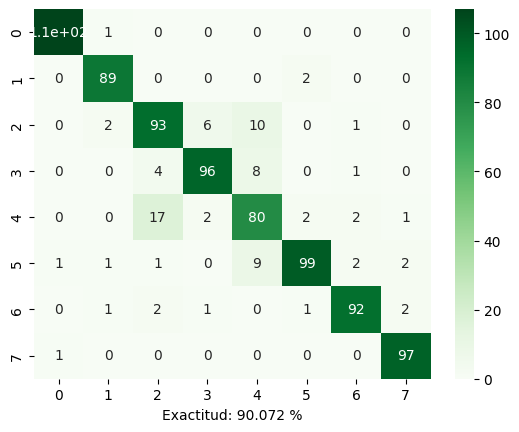

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       108
           1       0.95      0.98      0.96        91
           3       0.79      0.83      0.81       112
           4       0.91      0.88      0.90       109
           6       0.75      0.77      0.76       104
           9       0.95      0.86      0.90       115
          10       0.94      0.93      0.93        99
          11       0.95      0.99      0.97        98

    accuracy                           0.90       836
   macro avg       0.90      0.90      0.90       836
weighted avg       0.90      0.90      0.90       836



In [25]:
sns.heatmap(confusion_matrix(y_pred_RanF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF, y_test))

Validation data

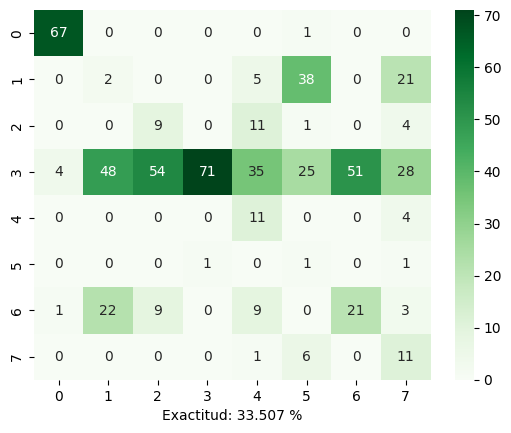

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        68
           1       0.03      0.03      0.03        66
           3       0.12      0.36      0.19        25
           4       0.99      0.22      0.37       316
           6       0.15      0.73      0.25        15
           9       0.01      0.33      0.03         3
          10       0.29      0.32      0.31        65
          11       0.15      0.61      0.24        18

    accuracy                           0.34       576
   macro avg       0.34      0.45      0.30       576
weighted avg       0.70      0.34      0.37       576



In [26]:
sns.heatmap(confusion_matrix(y_pred_RanF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_val, y_val))

Rotation forest

Test data

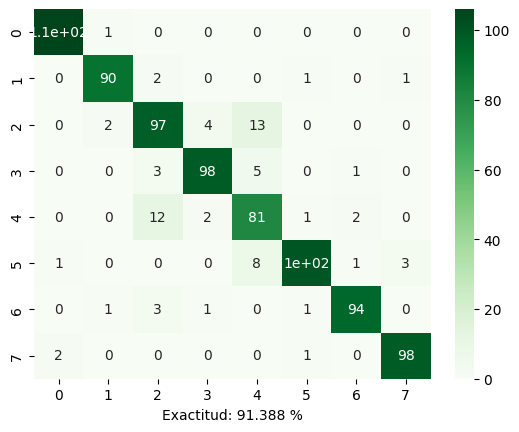

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       107
           1       0.96      0.96      0.96        94
           3       0.83      0.84      0.83       116
           4       0.93      0.92      0.92       107
           6       0.76      0.83      0.79        98
           9       0.96      0.88      0.92       113
          10       0.96      0.94      0.95       100
          11       0.96      0.97      0.97       101

    accuracy                           0.91       836
   macro avg       0.92      0.92      0.92       836
weighted avg       0.92      0.91      0.91       836



In [27]:
sns.heatmap(confusion_matrix(y_pred_RotF, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF, y_test))

Validation data

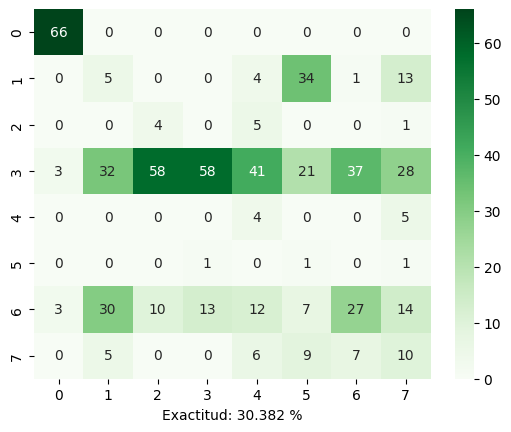

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        66
           1       0.07      0.09      0.08        57
           3       0.06      0.40      0.10        10
           4       0.81      0.21      0.33       278
           6       0.06      0.44      0.10         9
           9       0.01      0.33      0.03         3
          10       0.38      0.23      0.29       116
          11       0.14      0.27      0.18        37

    accuracy                           0.30       576
   macro avg       0.30      0.37      0.26       576
weighted avg       0.59      0.30      0.35       576



In [28]:
sns.heatmap(confusion_matrix(y_pred_RotF_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_val, y_val))

Artificial Neural Networks (ANN)

Test data

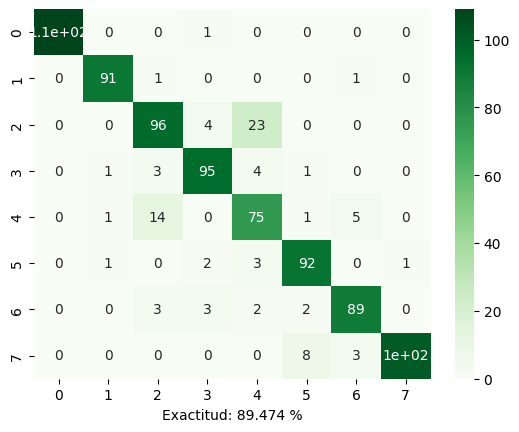

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       110
           1       0.97      0.98      0.97        93
           3       0.82      0.78      0.80       123
           4       0.90      0.91      0.91       104
           6       0.70      0.78      0.74        96
           9       0.88      0.93      0.91        99
          10       0.91      0.90      0.90        99
          11       0.99      0.90      0.94       112

    accuracy                           0.89       836
   macro avg       0.90      0.90      0.90       836
weighted avg       0.90      0.89      0.90       836



In [29]:
sns.heatmap(confusion_matrix(y_pred_ann, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann, y_test))

Validation data

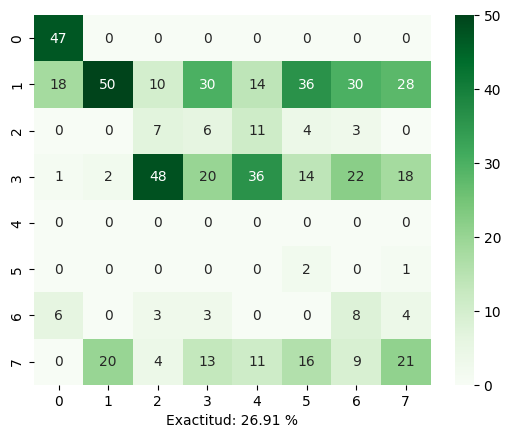

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        47
           1       0.69      0.23      0.35       216
           3       0.10      0.23      0.14        31
           4       0.28      0.12      0.17       161
           6       0.00      0.00      0.00         0
           9       0.03      0.67      0.05         3
          10       0.11      0.33      0.17        24
          11       0.29      0.22      0.25        94

    accuracy                           0.27       576
   macro avg       0.27      0.35      0.24       576
weighted avg       0.45      0.27      0.30       576



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [30]:
sns.heatmap(confusion_matrix(y_pred_ann_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_val, y_val))

# Con PCA

In [31]:
pca = PCA(n_components=80)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

X_pca_val = pca.transform(X_val)

In [32]:
print('Sin PCA')
print(X.shape)
print(X_pca.shape)
print('Con PCA')
print(X_val.shape)
print(X_pca_val.shape)

Sin PCA
(2784, 212)
(2784, 80)
Con PCA
(576, 212)
(576, 80)


Random forest

In [33]:
rf_pca = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=0,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_pca.fit(X_train_pca, y_train)
y_pred_RanF_pca = rf_pca.predict(X_test_pca)
y_pred_RanF_pca_val = rf_pca.predict(X_pca_val)

Rotation forest

In [34]:
clf_pca = RotationForest(n_estimators=300)
clf_pca.fit(X_train_pca, y_train)
y_pred_RotF_pca = clf_pca.predict(X_test_pca)
y_pred_RotF_pca_val = clf_pca.predict(X_pca_val)

Artificial Neural Networks (ANN)

In [35]:
le_pca = LabelEncoder()
y_train_enc = le_pca.fit_transform(y_train)  # Transforma las etiquetas a valores consecutivos (0 a 7)
y_test_enc = le_pca.transform(y_test)

# Asegurarse de que el número de clases sea correcto
num_classes = len(np.unique(y_train_enc))
print("Número de clases detectadas en y_train_b:", num_classes)  # Esto debería ser 8

# Convertir a formato categórico
y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat = to_categorical(y_test_enc, num_classes=num_classes)

# Definir y entrenar la red neuronal
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_pca.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')  # La capa de salida ahora usa 8 neuronas, una por clase
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train_pca, y_train_cat, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

# Predicción y decodificación
y_pred_probs = model.predict(X_test_pca)
y_pred_ann_e = np.argmax(y_pred_probs, axis=1)
y_pred_ann_pca = le_pca.inverse_transform(y_pred_ann_e)  # Convertir a las etiquetas originales

# Predicción y decodificación
y_pred_probs_val = model.predict(X_pca_val)
y_pred_ann_e_val = np.argmax(y_pred_probs_val, axis=1)
y_pred_ann_pca_val = le_pca.inverse_transform(y_pred_ann_e_val)  # Convertir a las etiquetas originales

Número de clases detectadas en y_train_b: 8


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


# Resultados

Random forest

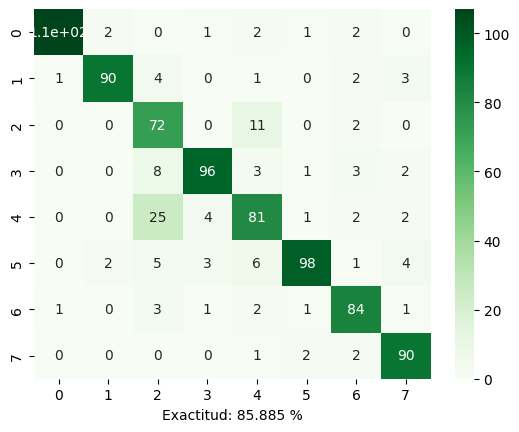

              precision    recall  f1-score   support

           0       0.98      0.93      0.96       115
           1       0.96      0.89      0.92       101
           3       0.62      0.85      0.71        85
           4       0.91      0.85      0.88       113
           6       0.76      0.70      0.73       115
           9       0.94      0.82      0.88       119
          10       0.86      0.90      0.88        93
          11       0.88      0.95      0.91        95

    accuracy                           0.86       836
   macro avg       0.86      0.86      0.86       836
weighted avg       0.87      0.86      0.86       836



In [36]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca, y_test))

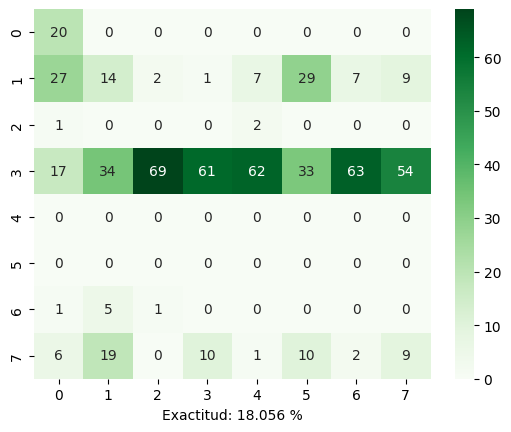

              precision    recall  f1-score   support

           0       0.28      1.00      0.43        20
           1       0.19      0.15      0.17        96
           3       0.00      0.00      0.00         3
           4       0.85      0.16      0.26       393
           6       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         0
          10       0.00      0.00      0.00         7
          11       0.12      0.16      0.14        57

    accuracy                           0.18       576
   macro avg       0.18      0.18      0.13       576
weighted avg       0.63      0.18      0.24       576



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [37]:
sns.heatmap(confusion_matrix(y_pred_RanF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RanF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RanF_pca_val, y_val))

Rotation forest

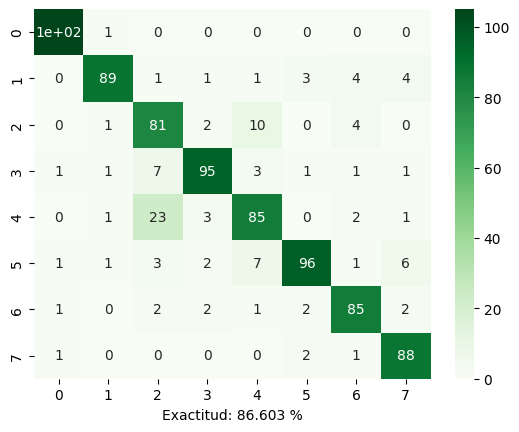

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       106
           1       0.95      0.86      0.90       103
           3       0.69      0.83      0.75        98
           4       0.90      0.86      0.88       110
           6       0.79      0.74      0.77       115
           9       0.92      0.82      0.87       117
          10       0.87      0.89      0.88        95
          11       0.86      0.96      0.91        92

    accuracy                           0.87       836
   macro avg       0.87      0.87      0.87       836
weighted avg       0.87      0.87      0.87       836



In [38]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca, y_test))

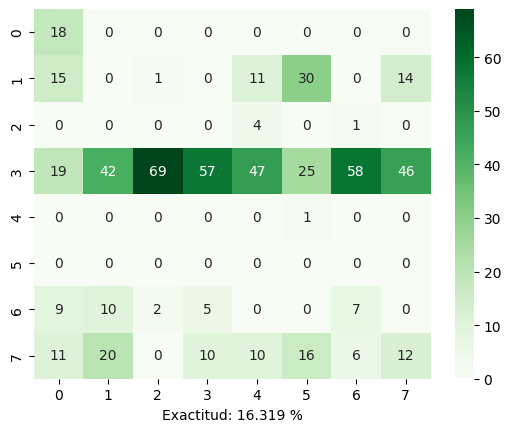

              precision    recall  f1-score   support

           0       0.25      1.00      0.40        18
           1       0.00      0.00      0.00        71
           3       0.00      0.00      0.00         5
           4       0.79      0.16      0.26       363
           6       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         0
          10       0.10      0.21      0.13        33
          11       0.17      0.14      0.15        85

    accuracy                           0.16       576
   macro avg       0.16      0.19      0.12       576
weighted avg       0.54      0.16      0.21       576



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [39]:
sns.heatmap(confusion_matrix(y_pred_RotF_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_RotF_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_RotF_pca_val, y_val))

Artificial Neural Networks (ANN)

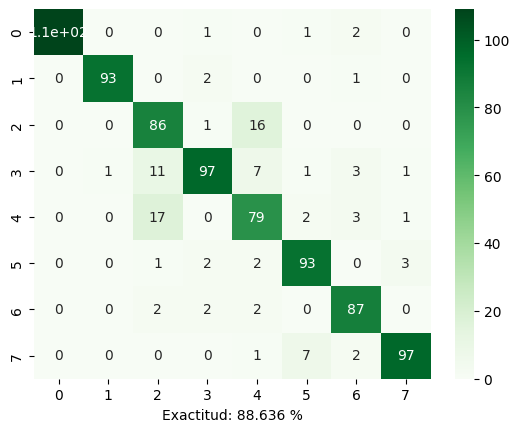

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       113
           1       0.99      0.97      0.98        96
           3       0.74      0.83      0.78       103
           4       0.92      0.80      0.86       121
           6       0.74      0.77      0.76       102
           9       0.89      0.92      0.91       101
          10       0.89      0.94      0.91        93
          11       0.95      0.91      0.93       107

    accuracy                           0.89       836
   macro avg       0.89      0.89      0.89       836
weighted avg       0.89      0.89      0.89       836



In [40]:
sns.heatmap(confusion_matrix(y_pred_ann_pca, y_test),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca, y_test),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca, y_test))

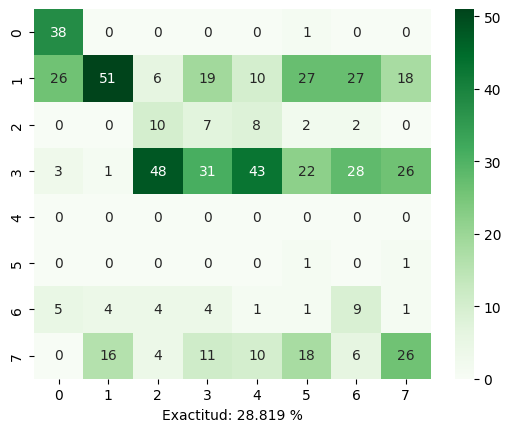

              precision    recall  f1-score   support

           0       0.53      0.97      0.68        39
           1       0.71      0.28      0.40       184
           3       0.14      0.34      0.20        29
           4       0.43      0.15      0.23       202
           6       0.00      0.00      0.00         0
           9       0.01      0.50      0.03         2
          10       0.12      0.31      0.18        29
          11       0.36      0.29      0.32        91

    accuracy                           0.29       576
   macro avg       0.29      0.36      0.25       576
weighted avg       0.48      0.29      0.32       576



c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

In [41]:
sns.heatmap(confusion_matrix(y_pred_ann_pca_val, y_val),cmap="Greens",annot=True)
plt.xlabel(f'Exactitud: {round(100*accuracy_score(y_pred_ann_pca_val, y_val),3)} %')
plt.show()
print(classification_report(y_pred_ann_pca_val, y_val))

Rpoerte de PCA

In [42]:
X

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,rms_2,iemg_2,mav_2,wl_2,...,fft_14,psd_14,mf_14,mdf_14,zc_14,ssc_14,df_14,sk_14,br_14,stimulus
0,-0.216788,-0.145370,-0.310003,-0.199759,-0.177375,-0.241029,0.122315,0.550061,0.390810,0.692949,...,-0.210522,0.971187,-0.502074,0.327073,-0.559446,-0.731662,0.420349,-0.269093,-0.292995,0.0
1,0.009700,-0.055476,0.056048,-0.072439,0.042362,-0.178394,0.494803,0.504927,0.641511,0.691840,...,-0.549329,0.211325,-0.506515,0.485626,-0.752203,-1.139443,-0.209210,-0.156460,-0.518804,0.0
2,-1.028566,-1.168642,-1.025140,-1.069589,-0.947155,-0.847933,-0.424363,-0.739916,-0.547706,-0.682644,...,-0.885763,2.893235,-0.678185,0.644179,-1.137718,-1.093104,0.756979,-0.555463,-0.641189,0.0
3,-0.288239,-0.028003,-0.185168,-0.068675,0.043350,-0.298140,0.215811,0.510847,0.361330,0.668090,...,-0.139177,0.786094,-0.659563,0.168520,-0.495194,-0.787269,-0.662286,-0.407314,-0.196485,0.0
4,-0.532904,-0.604536,-0.574692,-0.615651,-0.503853,-0.537866,0.203172,0.144152,0.224681,0.291715,...,-0.319703,0.226533,-0.440351,0.009967,-0.891417,-1.009695,-1.078403,-0.153031,-0.169748,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2779,-1.196250,-1.562534,-1.644325,-1.575450,-1.807329,-0.874183,-1.764577,-1.716563,-1.778108,-1.696052,...,1.064045,-0.485864,1.148765,0.802732,1.004028,1.001406,-0.606335,-0.653855,-0.450280,0.0
2780,-0.995307,-0.956252,-1.124505,-1.101192,-1.362070,-0.743470,-1.544407,-1.429802,-1.535812,-1.452951,...,1.408588,-0.373965,1.243873,0.802732,1.817891,1.344312,1.322947,-0.416218,-0.595982,0.0
2781,-1.587742,-1.765262,-1.867513,-1.713188,-1.958991,-1.020889,-1.695547,-1.704721,-1.768470,-1.693812,...,1.155266,-0.284968,1.250608,1.119838,1.432377,1.279438,-0.334949,-0.769361,-0.633313,0.0
2782,-1.076579,-0.952126,-1.113202,-1.084792,-1.053442,-0.787816,-1.564988,-1.449113,-1.551337,-1.463254,...,1.271353,-0.306310,0.999846,0.485626,1.368124,1.594541,-0.144829,-0.526254,-0.208714,0.0
